--- Starting Multi-Scenario Projection Plotting ---
Reading file: E:\Projetos\ABMS-WP\resultados\consumo_previsto_todos_cenarios.csv
Scenarios identified: 18
Chart successfully saved to: E:\Projetos\ABMS-WP\figuras\grafico_projecao_consumo_cenarios.pdf


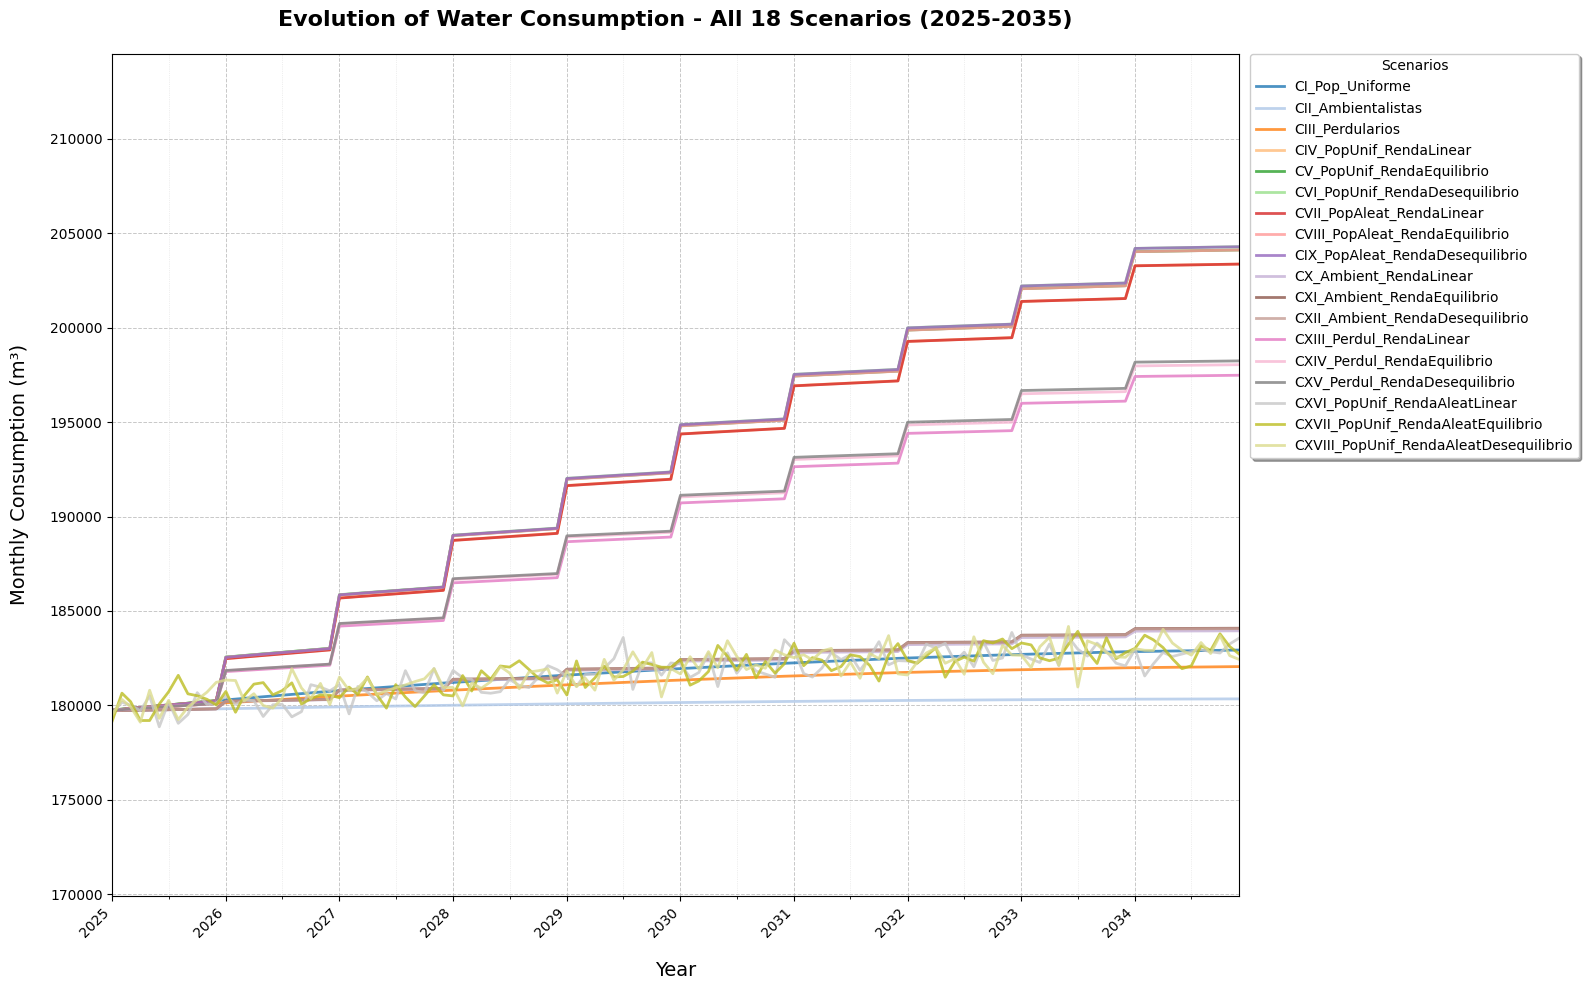

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter
import matplotlib.dates as mdates
import seaborn as sns
import os

# ==========================================
# 1. Configuration and Constants
# ==========================================

# Base Paths (Uncomment the active path)
BASE_PATH = 'E:\\Projetos\\ABM-WP' # Currently active path

# File names
INPUT_FILE = 'consumo_previsto_todos_cenarios.csv'
OUTPUT_FILE = 'grafico_projecao_consumo_cenarios.pdf'

# Subfolders
INPUT_DIR = os.path.join(BASE_PATH, 'resultados') # Assuming the CSV is in resultados
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras') # Saving figures in includes/figuras

def main():
    print("--- Starting Multi-Scenario Projection Plotting ---")

    # ==========================================
    # 2. Load Data
    # ==========================================
    file_path = os.path.join(INPUT_DIR, INPUT_FILE)
    
    # Check if file exists to avoid errors
    if not os.path.exists(file_path):
        # Fallback to try finding it in the root or includes if not in resultados
        file_path = os.path.join(BASE_PATH, INPUT_FILE)
        if not os.path.exists(file_path):
            print(f"Error: File not found at {file_path}")
            return

    print(f"Reading file: {file_path}")
    
    # Load CSV using correct delimiters for Brazilian format
    # sep=';' and decimal=',' based on the snippet provided
    df = pd.read_csv(file_path, sep=';', decimal=',')

    # ==========================================
    # 3. Data Processing
    # ==========================================
    
    # Create Date column
    # Assuming 'Mes' and 'Ano' columns exist or 'Mes_Ano'
    if 'Mes' in df.columns and 'Ano' in df.columns:
        df['Date'] = pd.to_datetime(df['Ano'].astype(str) + '-' + df['Mes'].astype(str) + '-01')
    elif 'Mes_Ano' in df.columns:
        df['Date'] = pd.to_datetime(df['Mes_Ano'], format='%m/%Y')
    
    # Identify Scenario Columns
    # Assuming the first few columns are Date related (Mes, Ano, Mes_Ano)
    # We select all columns that are NOT date related
    date_cols = ['Mes', 'Ano', 'Mes_Ano', 'Date']
    scenario_cols = [col for col in df.columns if col not in date_cols]
    
    print(f"Scenarios identified: {len(scenario_cols)}")

    # ==========================================
    # 4. Plotting
    # ==========================================
    
    # Use a high-contrast palette for 18 lines
    # 'tab20' is good for distinct colors up to 20 items
    colors = plt.cm.tab20(range(len(scenario_cols)))
    
    plt.figure(figsize=(16, 10))
    ax = plt.gca()

    # Loop through each scenario and plot
    for idx, col in enumerate(scenario_cols):
        plt.plot(df['Date'], df[col], 
                 label=col, 
                 color=colors[idx], 
                 linewidth=2, 
                 alpha=0.8)

    # ==========================================
    # 5. Formatting
    # ==========================================
    
    # X-axis settings
    ax.xaxis.set_major_locator(YearLocator())   # Major ticks for each year
    ax.xaxis.set_minor_locator(MonthLocator(bymonth=[7])) # Minor ticks mid-year
    ax.xaxis.set_major_formatter(DateFormatter('%Y')) # Show only year
    
    # Titles and Labels (in English)
    plt.title('Evolution of Water Consumption - All 18 Scenarios (2025-2035)', 
              fontsize=16, pad=20, fontweight='bold')
    plt.xlabel('Year', fontsize=14, labelpad=15)
    plt.ylabel('Monthly Consumption (m³)', fontsize=14, labelpad=15)
    
    # Grid
    plt.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.7)
    plt.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.4)

    # Legend - Placed outside the plot to accommodate 18 items
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0., 
               fontsize=10, title="Scenarios", frameon=True, shadow=True)

    # Limits
    plt.xlim([df['Date'].min(), df['Date'].max()])
    
    # Add simple Y-axis margin
    y_min = df[scenario_cols].min().min()
    y_max = df[scenario_cols].max().max()
    plt.ylim(y_min * 0.95, y_max * 1.05)

    # Rotate dates
    plt.xticks(rotation=45, ha='right')
    
    # Adjust layout to make room for external legend
    plt.tight_layout()

    # ==========================================
    # 6. Saving
    # ==========================================
    
    # Create output directory if needed
    if not os.path.exists(OUTPUT_DIR):
        try:
            os.makedirs(OUTPUT_DIR)
            print(f"Directory created: {OUTPUT_DIR}")
        except OSError as e:
            print(f"Error creating directory: {e}")

    full_output_path = os.path.join(OUTPUT_DIR, OUTPUT_FILE)
    
    # Save as PDF (Vector format for articles)
    plt.savefig(full_output_path, format='pdf', bbox_inches='tight')
    
    print(f"Chart successfully saved to: {full_output_path}")
    
    plt.show()

if __name__ == "__main__":
    main()